<a href="https://colab.research.google.com/github/LuxorLu/LuxorLu/blob/main/Cohort%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```




Джерело даних: Online Retail Dataset (Kaggle / UCI Machine Learning Repository)

In [7]:
import os

# запускаємо токен
os.environ['KAGGLE_API_TOKEN'] = "KGAT_b04084eefe3168b08b773a15b4d3478a"

# встановлюємо бібліотеку kaggle та скачуємо датасет напряму
!pip install kaggle -q
!kaggle datasets download -d vijayuv/onlineretail --unzip

print("Файл успішно завантажено!")

Dataset URL: https://www.kaggle.com/datasets/vijayuv/onlineretail
License(s): CC0-1.0
100% 7.20M/7.20M [00:00<00:00, 247MB/s]

Файл успішно завантажено!


Підключаємо додаткову бібліотеку PANDAS
Зчитаємо його у таблицю Pandas, щоб побачити дані:

In [10]:
import pandas as pd

# Зчитуємо завантажений та розархівований файл
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

# Показуємо перші 5 рядків таблиці
df.head()



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


дізнаємося загальну інформацію: скільки всього рядків у таблиці, які типи даних і чи є пусті клітинки.

In [11]:
# Перевіряємо розмір таблиці (рядки, колонки) та типи даних
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [13]:
# Залишаємо тільки ті рядки, де CustomerID НЕ порожній (notna)
df = df[df['CustomerID'].notna()]

# Перевіряємо кількість рядків
print("Залишилося рядків:", len(df))

Залишилося рядків: 406829


In [14]:
# Залишаємо тільки покупки з додатною кількістю та ціною > 0
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Перевіряємо, скільки рядків залишилося після прибирання повернень
print("Залишилося чистих покупок:", len(df))

Залишилося чистих покупок: 397884


In [15]:
# Перетворюємо текст на справжній формат дати
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Перевіряємо, чи змінився тип колонки
df.dtypes['InvoiceDate']

dtype('<M8[ns]')

In [16]:
# 1. Створюємо колонку з місяцем покупки (наприклад, 2010-12)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 2. Знаходимо найперший місяць покупки для кожного клієнта (Когорту)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

# Показуємо перші 5 рядків з новими колонками
df[['CustomerID', 'InvoiceDate', 'InvoiceMonth', 'CohortMonth']].head()

,CustomerID,InvoiceDate,InvoiceMonth,CohortMonth
0,17850.0,2010-12-01 08:26:00,2010-12,2010-12
1,17850.0,2010-12-01 08:26:00,2010-12,2010-12
2,17850.0,2010-12-01 08:26:00,2010-12,2010-12
3,17850.0,2010-12-01 08:26:00,2010-12,2010-12
4,17850.0,2010-12-01 08:26:00,2010-12,2010-12


In [17]:
# Рахуємо різницю в місяцях між покупкою та першою покупкою (когортою)
df['CohortIndex'] = (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 + \
                    (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)

# Перевіряємо перші 5 рядків
df[['CustomerID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head()

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850.0,2010-12,2010-12,0
1,17850.0,2010-12,2010-12,0
2,17850.0,2010-12,2010-12,0
3,17850.0,2010-12,2010-12,0
4,17850.0,2010-12,2010-12,0


In [18]:
# 1. Рахуємо унікальних клієнтів за CohortMonth та CohortIndex
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

# 2. Робимо зведену таблицю (Pivot Table)
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# 3. Виводимо підсумкову таблицю
cohort_counts

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# 1. Беремо розмір когорти з першої колонки (index 0)
cohort_sizes = cohort_counts.iloc[:, 0]

# 2. Ділимо кожну колонку на початковий розмір когорти, щоб отримати %
retention = cohort_counts.divide(cohort_sizes, axis=0)

# 3. Округлюємо відсотки та виводимо таблицю
retention.round(3) * 100

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


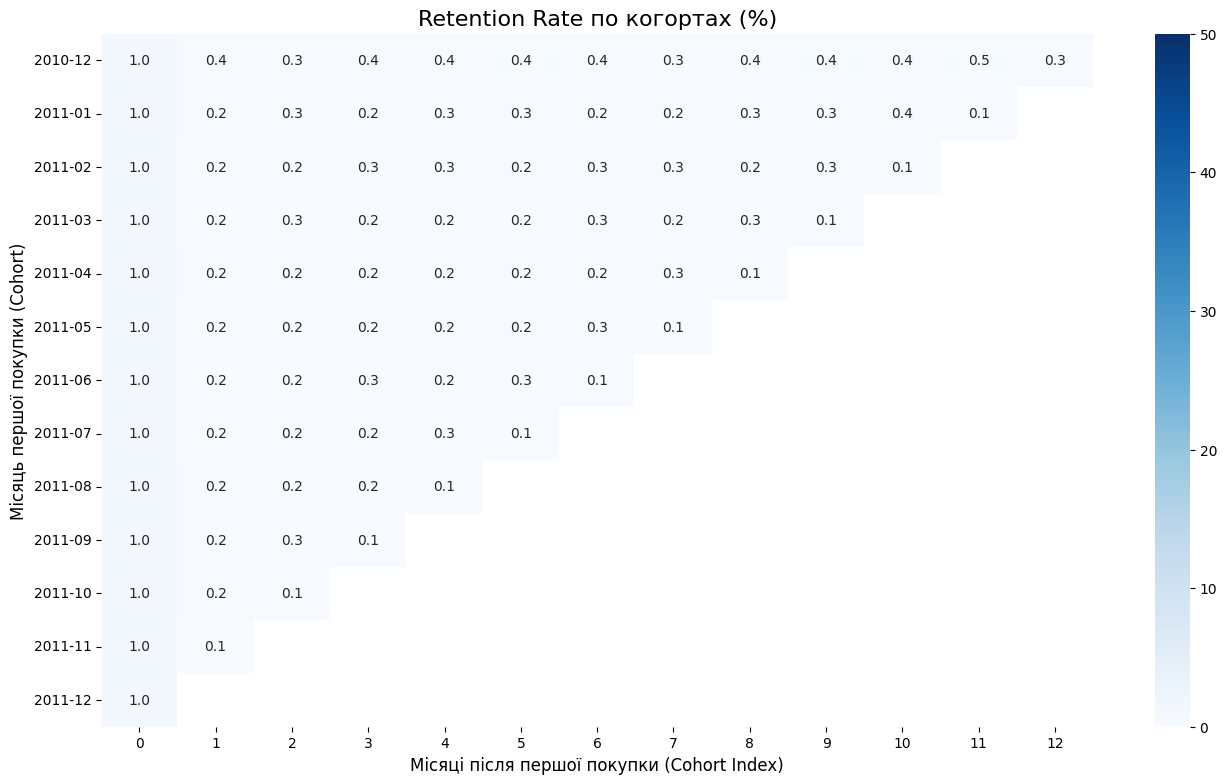

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Встановлюємо розмір графіка
plt.figure(figsize=(16, 9))

# Малюємо теплову карту
sns.heatmap(
    data=retention,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=50
)

plt.title('Retention Rate по когортах (%)', fontsize=16)
plt.xlabel('Місяці після першої покупки (Cohort Index)', fontsize=12)
plt.ylabel('Місяць першої покупки (Cohort)', fontsize=12)

plt.show()

Dataset URL: https://www.kaggle.com/datasets/vijayuv/onlineretail
License(s): CC0-1.0
100% 7.20M/7.20M [00:00<00:00, 127MB/s]



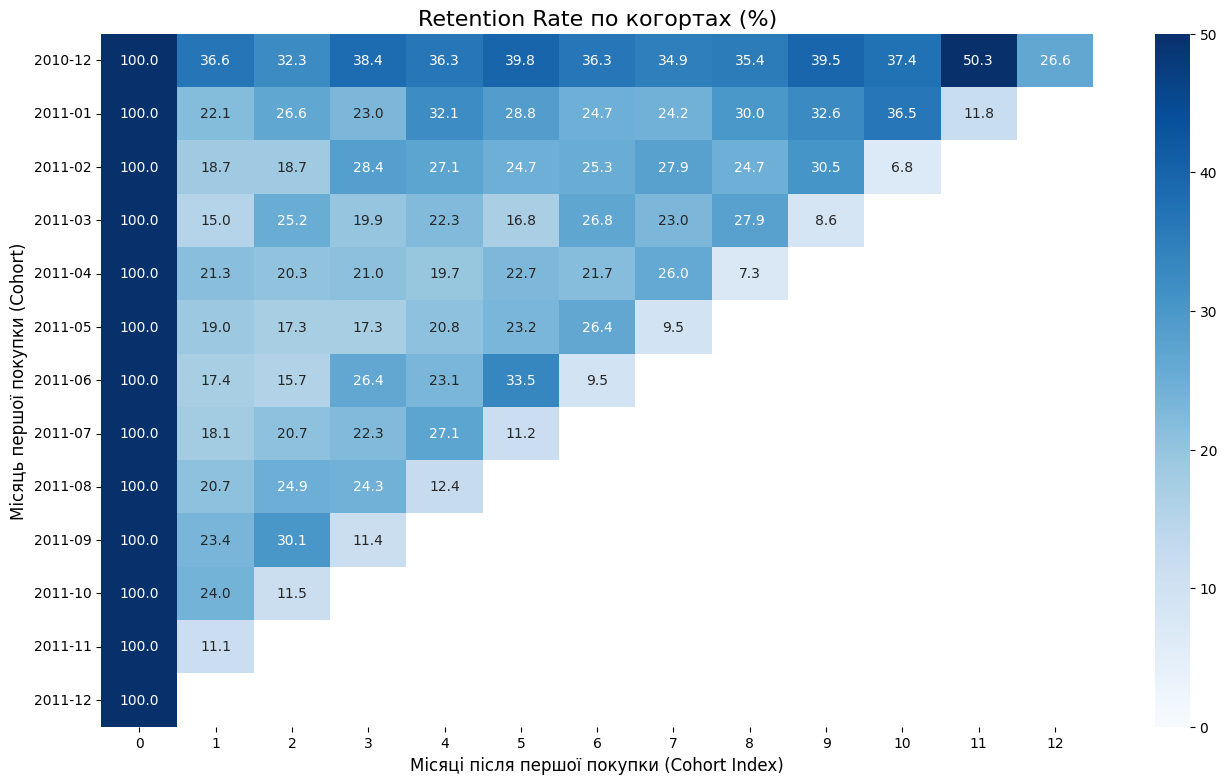

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Завантажуємо датасет через Kaggle API
os.environ['KAGGLE_API_TOKEN'] = "KGAT_b04084eefe3168b08b773a15b4d3478a"
!kaggle datasets download -d vijayuv/onlineretail --unzip

# 2. Зчитуємо та очищаємо дані
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

# Видаляємо порожні CustomerID та повернення товару
df = df[df['CustomerID'].notna()]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Перетворюємо дату на тип datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Формуємо когорти та розраховуємо CohortIndex
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

df['CohortIndex'] = (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 + \
                    (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)

# 4. Створюємо зведену таблицю (Pivot Table)
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# 5. Розраховуємо Retention Rate (%)
cohort_sizes = cohort_counts.iloc[:, 0]
retention_pct = cohort_counts.divide(cohort_sizes, axis=0) * 100

# 6. Малюємо красиву теплову карту (Heatmap)
plt.figure(figsize=(16, 9))

sns.heatmap(
    data=retention_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    vmax=50
)

plt.title('Retention Rate по когортах (%)', fontsize=16)
plt.xlabel('Місяці після першої покупки (Cohort Index)', fontsize=12)
plt.ylabel('Місяць першої покупки (Cohort)', fontsize=12)

plt.show()